In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many charcters do we take to predict the next one


def build_dataset(words):
    X, Y = [], []

    for w in words:
        # print(w)
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # 0.3 according to kaiming paper # 0.2 # to scale down the preactivations and tanh activations
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # to scale down the preactivations and tanh activations. we can also make this zero
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # scaling W2 down to decrease the intial loss
b2 = torch.randn(vocab_size,                      generator=g) * 0 # keeping inital bias zero, to avoid arbitrarily large numbers and decrease the intial loss

# scale and shift parameters from batch norm paper
# batch norm becomes more useful for larger networks, where we select particular linear/convolutional (input * weight + bias) layers to append after to.
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [12]:
(torch.randn(10000) * 0.2).std()

tensor(0.1977)

In [13]:
# According to Kaiming init paper proper initialization factor is = gain / sqrt(fan_mode)
# gain is defined for each type of activation function - tanh: 5/3, relu: sqrt(2), linear: 1
# fan_mode can be the number of cells in fan_in (default), or fan_out. Our network has 30 inputs (block_size * n_embd) for W1.
(5/3) / (30**0.5)

0.3042903097250923

tensor(-0.0152) tensor(1.0112)
tensor(-0.0016) tensor(0.9843)


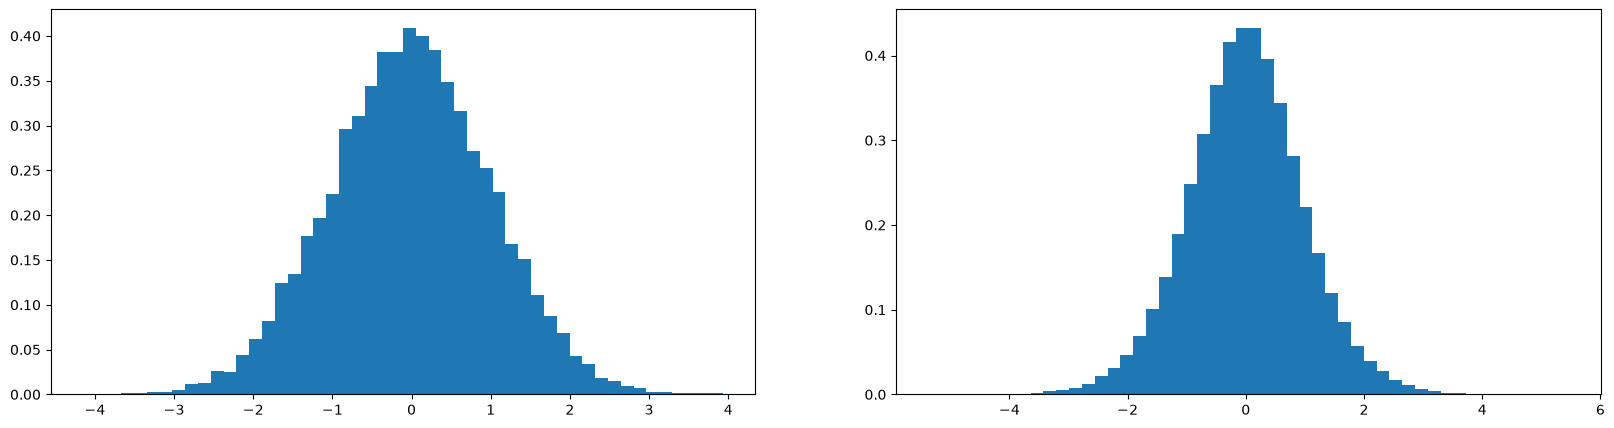

In [14]:
x = torch.randn(1000, 10) # randn uses gaussian/normal distribution.
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [17]:
hpreact.shape

torch.Size([32, 200])

In [19]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [20]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed charaters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

    # Linear layer
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation
    # due to batchnorm, bias additon becomes redundant since it will cancel out in the numerator (see below).
    # Instead we will have batch normalization bias (bnbias) as seen below.

    # BatchNorm layer
    # -------------------------------------------------------------
    # these params are to calculate mean and std while training and not afterwards.
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)

    hpreact = bngain * ((hpreact - bnmeani) / bnstdi) + bnbias # standardize the values according to batch norm paper and apply scale and shift using bngain and bnbias. 
    # Basically what we are doing above is simply making the preactivations follow a string guassian distribution 
    # since that is the idea distribution for activation function. One drawback is that we only want to 
    # normalize once intially and allow neural net to shift the distribution around on it own, we don't 
    # want to normalize in every pass. To handle this we use scale and shift. 
    # In the first step the normalized params will follow unit gaussian, and later bngain and bnbias 
    # will be trained during backprop.
    # Another abnormal thing is that previously hpreact previously was only a function of the input 
    # example, but now that its coupled with other examples randomly selected in the batch due to batchnorm. 
    # It also becomes a function of other examples in the batch. 
    # This will cause a random jitter in the h and logits depending on what examples are there in the batch.
    # An onvious thought would be that this is undesirable element, but it turns out to be a good side effect for neural net training.
    # The reason is that this jitter introduces a bit of entropy and is padding out any one of these examples.
    # It is like augmenting the input jittering it, making it difficult for the network to overfit.
    # So batchnorm acts as a regularizer as a second order effect. 
    # An this makes it harder to remove the use of batchnorm because of the jitter , which is not preferred. There are other normalization techniques which do not couple examples
    
    # In the batch norm paper a small value epsilon (say 1e-5) is added to the std in the denominator. That is to prevent division by 0 when std/variance is 0.

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    # break
# print(loss.item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


In [ ]:
# Batch normalization, in brief
#
# We use batch norm to control the statistics of activations in the net.
# It is common to sprinkle it after layers that multiply (linear or conv).
#
# Parameters (trained with backprop):
#   - gain (bngain) and bias (bnbias)
#
# Buffers (not trained with backprop; updated as a running average):
#   - running mean and running std of the inputs
#
# What it does on each training batch:
#   1. measure mean and std of the incoming activations over the batch
#   2. center/scale that batch to unit Gaussian
#   3. scale and shift with the learned gain and bias
#   4. also fold the batch stats into the running mean/std
#
# At inference we freeze those running buffers so we can forward a single
# example without re-estimating mean and std from a batch.

In [17]:
# The initial loss is 27.8817 (see the part 2 notebook), which is very high. At initialization, we have no reason to believe 
# that some characters are more likely so we expect a uniform distribution where prob of each char = 1/27.
expected_inital_loss = -torch.tensor(1/27.0).log()
expected_inital_loss

tensor(3.2958)

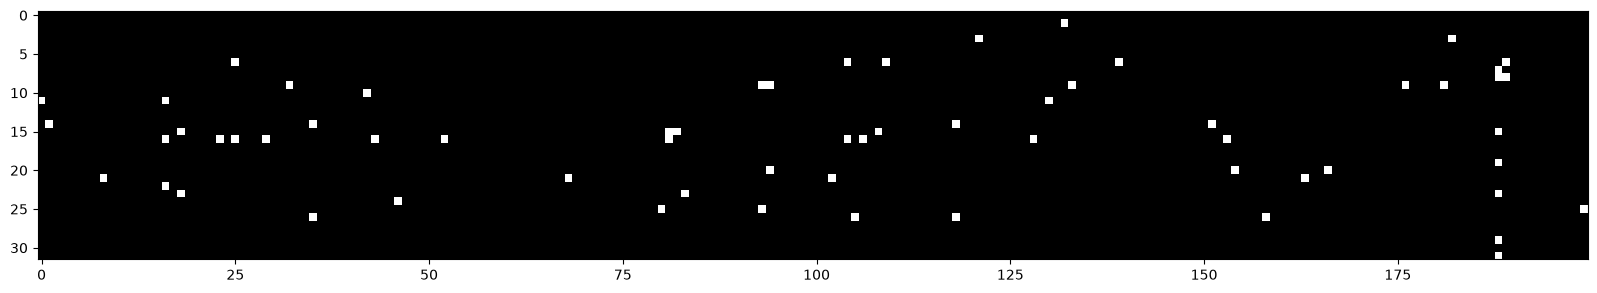

In [18]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')
# whites show values 1, -1. for these values gradient becomes zero during backprop 
# see derivative of tanh and put 1, -1 in that. 
# if all activations of a neuron are 1, -1, then that is dead neuron (never learns)

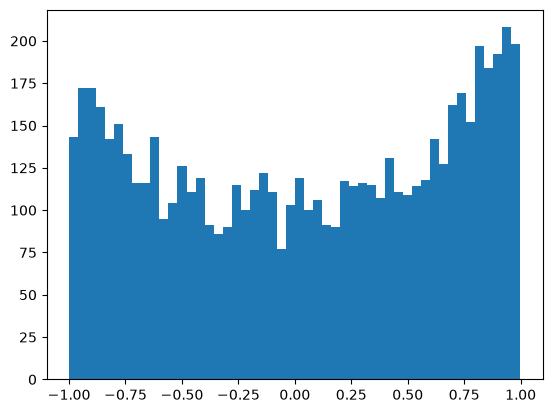

In [19]:
plt.hist(h.view(-1).tolist(), 50); # most values are one or -1, 1. too saturated towards the ends (before we scale down b1 and W1).
# After scaling down the values are with -1, 1 range.

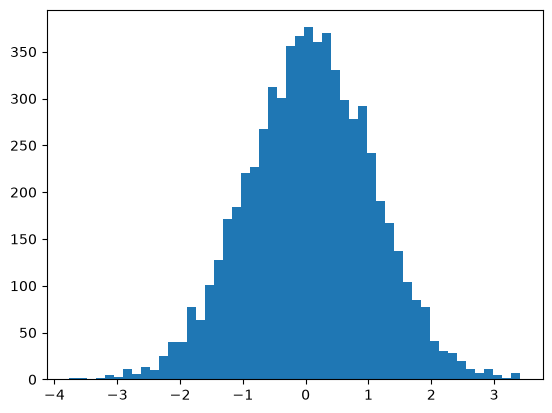

In [20]:
plt.hist(hpreact.view(-1).tolist(), 50); # very broad set of values as shown in the fig.

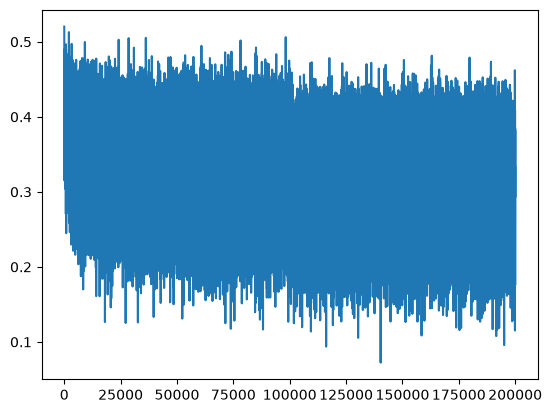

In [24]:
plt.plot(lossi)

In [ ]:
# batch norm expects mean and std for batches as input, but we do not have that after model deployment
# when we only want to test against single examples

# calibrate the batch norm at the end of the training (this is not needed since we calculated the mean and std during training)

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [37]:
bnmean, bnstd

(tensor([[-2.3355,  0.6776, -0.9133,  1.0163,  1.0865,  1.0938,  1.7437, -2.1208,
           0.5730,  1.4455, -1.6344, -2.7372, -0.4752, -0.1412, -0.0745, -1.1722,
           0.6851, -2.6219, -0.1065,  1.6326, -0.7706, -0.3063,  0.0479,  0.6115,
           1.1173,  0.2427,  2.0500,  0.5831,  0.8527,  1.7680, -0.3625, -0.8356,
          -0.0854, -0.5177, -0.3805, -1.0698, -0.0786,  0.3487, -0.5808,  0.9875,
          -0.4427, -1.3082, -0.2871, -0.2332,  0.6850,  0.6850,  2.0857, -0.7608,
           2.3866,  1.8734,  0.8260,  0.2803,  1.8897,  0.4709,  0.6739, -1.8940,
          -0.0401,  0.4338,  1.3760, -0.8910, -0.4524,  1.1754,  0.5613,  0.6051,
           1.5858,  1.2260, -1.0111,  2.1495, -0.6393,  0.0938, -0.2864, -0.4856,
           0.9632, -1.0461, -2.9990,  0.6391,  1.4327, -0.1590,  0.0941,  0.5253,
           0.2508,  1.2521,  2.0388,  0.6608,  0.0691, -0.0813, -1.6723,  0.2933,
           2.2423, -0.0210, -0.6666,  1.4253, -0.8412, -1.2248, -1.0128,  0.2230,
           0.211

In [38]:
bnmean_running, bnstd_running

(tensor([[-2.3539,  0.6872, -0.9000,  1.0159,  1.0894,  1.0862,  1.7389, -2.1356,
           0.5608,  1.4246, -1.6445, -2.7426, -0.4861, -0.1510, -0.0687, -1.1550,
           0.6891, -2.6399, -0.1283,  1.6240, -0.7732, -0.2865,  0.0467,  0.6119,
           1.1172,  0.2433,  2.0542,  0.5778,  0.8515,  1.7729, -0.3741, -0.8385,
          -0.0831, -0.5198, -0.3816, -1.0698, -0.0780,  0.3370, -0.5769,  0.9935,
          -0.4507, -1.3313, -0.2894, -0.2299,  0.6877,  0.6936,  2.0835, -0.7759,
           2.3804,  1.8614,  0.8118,  0.2735,  1.8802,  0.4705,  0.6656, -1.8962,
          -0.0420,  0.4355,  1.3924, -0.8906, -0.4676,  1.1688,  0.5539,  0.6001,
           1.5853,  1.2103, -1.0171,  2.1422, -0.6330,  0.1070, -0.2926, -0.4831,
           0.9506, -1.0144, -2.9925,  0.6269,  1.4404, -0.1574,  0.0955,  0.5159,
           0.2487,  1.2400,  2.0104,  0.6695,  0.0768, -0.0851, -1.6767,  0.2963,
           2.2374, -0.0100, -0.6669,  1.4356, -0.8431, -1.2317, -1.0220,  0.2201,
           0.192

In [39]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat in (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * ((hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066591501235962
val 2.1050572395324707


In [ ]:
# loss log

# original
#    train 2.1267659664154053
#    val 2.1697638034820557

# fix softmax confidently wrong
#    train 2.0695888996124268
#    val 2.131074905395508

# fix tanh layer too saturated at init
#    train 2.0355966091156006
#    val 2.1026782989501953

# use a semi principled "kaiming init" instead of a hacky init:
#    train 2.0376641750335693
#    val 2.1046782989501953

# add a batch norm layer
#    train 2.0668270587921143
#    val 2.104844808578491

In [15]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    # forward pass the neural net
    out = []
    context = [0] * block_size # inititalize with ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the current samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated words

carlah.
ambrie.
khy.
mili.
tatyah.
cassie.
rahnee.
deliah.
jarqui.
nellara.
chaiir.
kaleigh.
ham.
join.
quinthanourta.
jadiquinterri.
jaryxia.
kaellinsleee.
deciia.
gilee.


In [ ]:
# Same motif in a real network: ResNet Bottleneck (PyTorch torchvision)
# https://github.com/pytorch/vision/blob/6da25ff876100d36f23472f5762d5f306c47d735/torchvision/models/resnet.py#L108
#
# ResNet is a deep image-classification net made of repeating Bottleneck blocks
# stacked in series. __init__ creates the layers (like our parameter init);
# forward says how an input walks through them (like our training forward pass).
#
# Each block repeats: conv -> batchnorm -> ReLU. That is the same pattern as
# our MLP: linear (Wx+b) -> batchnorm -> tanh. Conv is Wx+b on overlapping
# image patches instead of the whole vector. ReLU vs tanh is just a different
# nonlinearity; ReLU usually works better in very deep nets. The skip/residual
# add at the end of Bottleneck is extra and not covered yet.
#
# Conv layers are created with bias=False for the same reason we dropped b1:
# batchnorm subtracts the mean (so a preceding bias is cancelled) and already
# has its own bnbias. Extra bias would be unused, not harmful.
#
# ---------------------------------------------------------------------------
# torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
# https://docs.pytorch.org/docs/2.14/generated/torch.nn.Linear.html
#
# y = x @ W.T + b  (same Wx+b we implement by hand). in_features / out_features
# are fan-in / fan-out so PyTorch knows the weight shape (out, in). Set
# bias=False when the next layer is batchnorm, as above. Weights, biases are initalized by
# default according to uniform distribution in range (-sqrt(k), sqrt(k)) where k = 1/in_features
#
# ---------------------------------------------------------------------------
# torch.nn.BatchNorm1d(num_features, eps=1e-5, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None)
# https://docs.pytorch.org/docs/2.14/generated/torch.nn.BatchNorm1d.html
#
# y = ((x - mean) / sqrt(var + eps)) * gamma + beta over the batch, per feature.
# gamma/beta are our bngain/bnbias (affine=True). running_mean / running_var
# are the buffers used at eval (track_running_stats=True). momentum here is the
# EMA rate: running = (1-momentum)*running + momentum*batch_stat (PyTorch default
# 0.1; we used 0.001), for large enough batch size larger values like 0.1 can be takes since
# mean is roughly the same for every batch. In our case we have a batch size of 32 which is small
# so we used a smaller value 0.001 which helps the value converge towards the actual mean. 
# eps avoids divide-by-zero. affine = True determines whether the batchnorm layer has learnable affine 
# params like bngain, bnbias (this looks like it should be true always, no sure when it can be false).
# track_running_stats determins whether the momentum average will be tracked or not, we can skip this 
# we want ot calculate the avg at the end like we did in a cell previously. 
# device is cpu or gpu. dtype is data type.

In [ ]:
# SUMMARY -------------

In [ ]:
# Let's train a deeper network

class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) #/ fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # params trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers trained with a running momentum update
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

n_embd = 10 # the dimensionality of character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

# Why are Tanh layers needed? Beacause they introduce non-linearity, if 
# we just have linear layers stacked (no matter how many), the resulting neural net can only 
# approximate linear functions, no any arbitrary function.
with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1 # changing this due to batchnorm being the last layer
    # layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0#5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

47551


In [90]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

    # forward pass
    emb = C[Xb] # embed the characters in vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER DEBUG: would take out retail_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 1.0 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 100000 == 0: # print every once in a while
        print(f'{i:7d}{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000: break # AFTER DEBUG: would take out to run full optimization

      0 200000: 2.5511


layer 2 (      Tanh): mean -0.01, std +0.63, saturated: 3.72%
layer 5 (      Tanh): mean -0.01, std +0.64, saturated: 3.72%
layer 8 (      Tanh): mean -0.04, std +0.65, saturated: 3.69%
layer 11 (      Tanh): mean -0.02, std +0.64, saturated: 3.53%
layer 14 (      Tanh): mean +0.03, std +0.64, saturated: 2.94%


Text(0.5, 1.0, 'activation distribution')

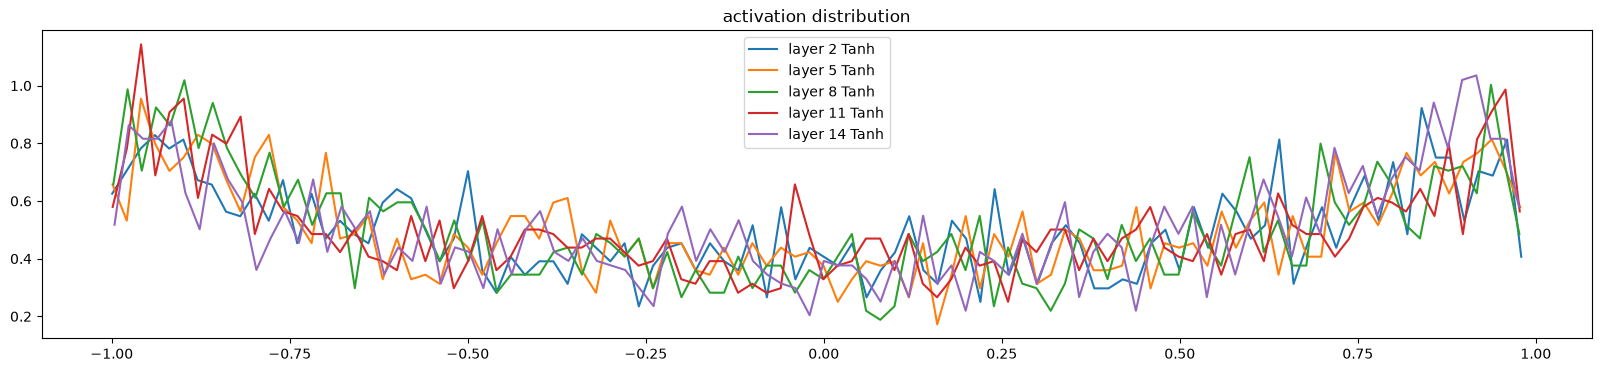

In [91]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plt
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %+.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.00, std +0.00, saturated: 0.00%
layer 5 (      Tanh): mean -0.00, std +0.00, saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std +0.00, saturated: 0.00%
layer 11 (      Tanh): mean +0.00, std +0.00, saturated: 0.00%
layer 14 (      Tanh): mean +0.00, std +0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

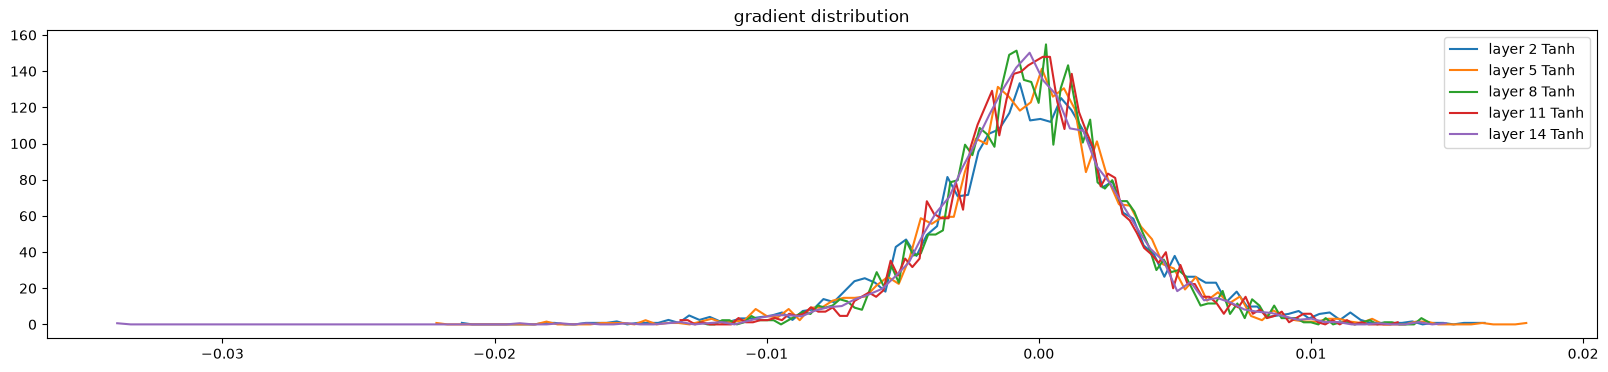

In [92]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plt
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %+.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weights   (27, 10) | mean +0.000000 | std 7.649570e-03 | grad:data ratio 7.376156e-03
weights  (30, 100) | mean -0.000024 | std 2.423733e-03 | grad:data ratio 2.357112e-03
weights (100, 100) | mean +0.000009 | std 1.260121e-03 | grad:data ratio 1.263105e-03
weights (100, 100) | mean +0.000012 | std 1.142147e-03 | grad:data ratio 1.133052e-03
weights (100, 100) | mean +0.000025 | std 1.121000e-03 | grad:data ratio 1.116831e-03
weights (100, 100) | mean -0.000005 | std 1.091422e-03 | grad:data ratio 1.086382e-03
weights  (100, 27) | mean -0.000028 | std 1.940927e-03 | grad:data ratio 1.959110e-03


Text(0.5, 1.0, 'weights gradient distribution')

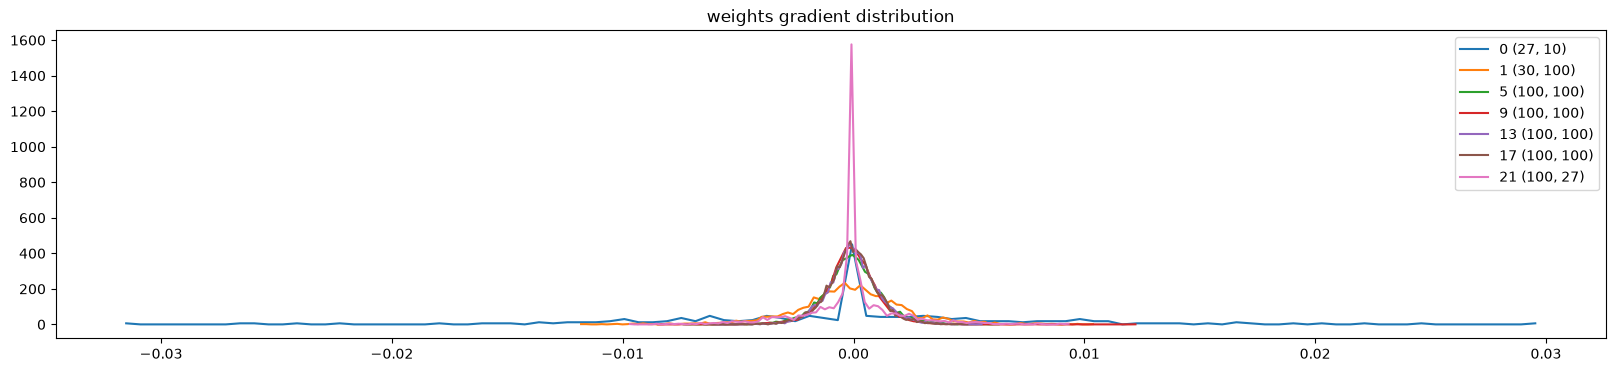

In [93]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plt
legends = []
for i, p in enumerate(parameters): # note: exclude the output layer
    t = p.grad
    if p.ndim == 2:
        print('weights %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends);
plt.title('weights gradient distribution')

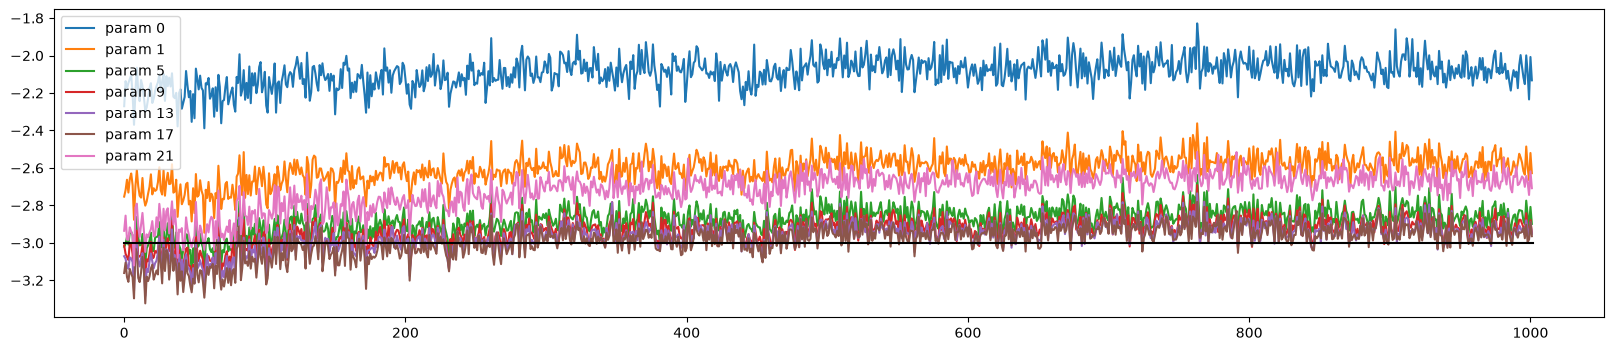

In [94]:
plt.figure(figsize=(20, 4)) # width and height of the plt
legends = []
for i, p in enumerate(parameters): # note: exclude the output layer
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be 1e-3, indicate on plot
plt.legend(legends);
# plt.title('update gradient distribution')